<a href="https://colab.research.google.com/github/Loopinlogix/Generative_AI_-Essentials/blob/main/GEN_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 13: Generative AI Essentials

This notebook demonstrates how to build and train a character-level Long Short-Term Memory (LSTM) neural network to generate text. The model learns to predict the next character in a sequence, effectively generating new text that resembles its training data.

1.  **Setup**: Import necessary libraries and set up the environment.
2.  **Download Data**: Obtain a text corpus (Pride and Prejudice) from Project Gutenberg.
3.  **Prepare Text**: Clean the text, create a vocabulary of unique characters, and convert text to numerical representations.
4.  **Create Training Data**: Formulate input-target sequences for the LSTM model.
5.  **Build Model**: Design a character-level LSTM model using TensorFlow/Keras.
6.  **Train Model**: Train the model on the prepared data.
7.  **Visualize Training**: Plot training and validation loss/accuracy to monitor performance.
8.  **Text Generation**: Implement functions to generate new text using the trained model, exploring the effect of 'temperature' on creativity.



In [12]:
#Github

# Github

# Clone a public GitHub repository
!git clone https://github.com/Loopinlogix/Generative_AI_-Essentials.git

# Change directory into the cloned repository (replace 'colabtools' with your repo name)
%cd Generative_AI_-Essentials

# List the contents of the directory
!ls


Cloning into 'Generative_AI_-Essentials'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Generative_AI_-Essentials
README.md


STEP 1: SETUP
TensorFlow version: 2.20.0
STEP 2: DOWNLOAD DATA FROM PROJECT GUTENBERG

Downloaded 743,353 characters

First 300 characters:
*** START OF THE PROJECT GUTENBERG EBOOK PRIDE AND PREJUDICE ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

   
STEP 3: PREPARE THE TEXT
Cleaned text: 713,111 characters

Vocabulary size: 44 unique characters
Characters:  !,-.0123456789:;?abcdefghijklmnopqrstuvwxyz

Example: 'start of the project' -> [36, 37, 18, 35, 37, 0, 32, 23, 0, 37, 25, 22, 0, 33, 35, 32, 27, 22, 20, 37]
STEP 4: CREATE TRAINING DATA
Total sequences: 713,011
Input shape: (713011, 100)
Target shape: (713011,)

Example:
Input:  'start of the project gutenberg ebook pride and prejudice illustration: george allen publisher 156 ch'
Target: 'a' (should be the next character)
STEP 5: BUILD THE MODEL
Model archi

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

STEP 6: TRAIN THE MODEL

Training the model...
This is like showing the model thousands of sentences
and asking it to guess the next character each time.

Epoch 1/20
5014/5014 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.4499 - loss: 1.8402 - val_accuracy: 0.5381 - val_loss: 1.5178
Epoch 2/20
5014/5014 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - accuracy: 0.5618 - loss: 1.4267 - val_accuracy: 0.5776 - val_loss: 1.3630
Epoch 3/20
5014/5014 ━━━━━━━━━━━━━━━━━━━━ 54s 11ms/step - accuracy: 0.5916 - loss: 1.3171 - val_accuracy: 0.5969 - val_loss: 1.2958
Epoch 4/20
5014/5014 ━━━━━━━━━━━━━━━━━━━━ 54s 11ms/step - accuracy: 0.6063 - loss: 1.2604 - val_accuracy: 0.6087 - val_loss: 1.2559
Epoch 5/20
5014/5014 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.6163 - loss: 1.2241 - val_accuracy: 0.6158 - val_loss: 1.2316
Epoch 6/20
5014/5014 ━━━━━━━━━━━━━━━━━━━━ 54s 11ms/step - accuracy: 0.6233 - loss: 1.1980 - val_accuracy: 0.6202 - val_loss: 1.2154
Epoch 7/20
5014/5014 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/st

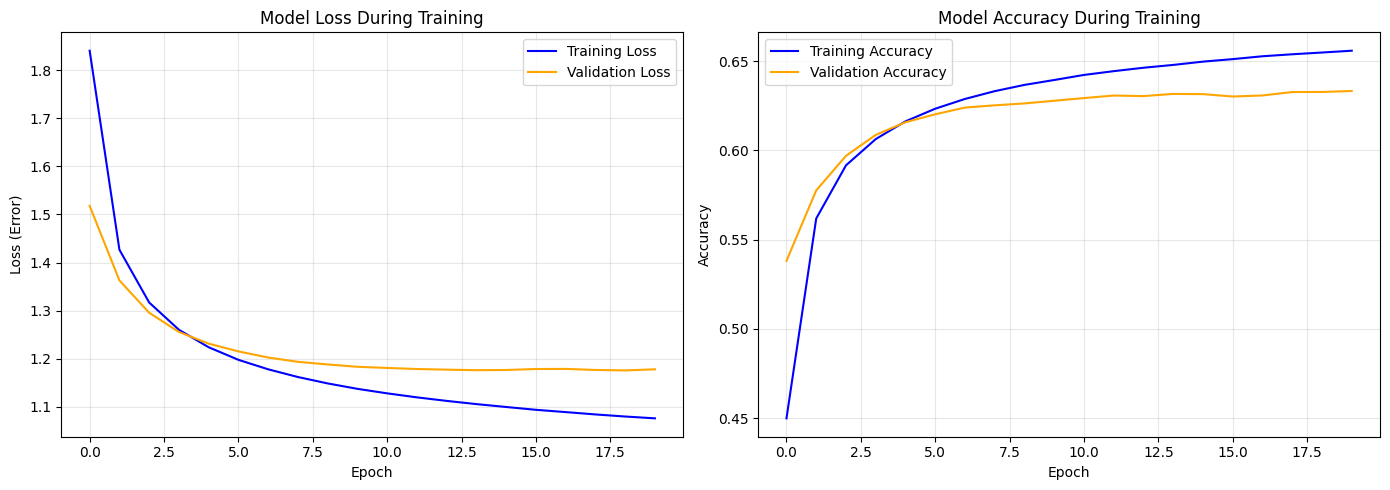


What these graphs mean:
- Loss: How wrong the model is (should go DOWN)
- Accuracy: How often it predicts correctly (should go UP)
- If validation loss goes UP while training loss goes DOWN,
  the model is 'overfitting' (memorizing, not learning)


In [2]:
print("=" * 60)
print("STEP 1: SETUP")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import requests
import re

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


print("=" * 60)
print("STEP 2: DOWNLOAD DATA FROM PROJECT GUTENBERG")
print("=" * 60)

def download_book(book_id):
    """
    Downloads a book from Project Gutenberg.
    Book ID 1342 = Pride and Prejudice
    """
    # The correct URL format for plain text
    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"

    print(f"Downloading from: {url}")
    response = requests.get(url)
    text = response.text

    # Find the actual book content (between START and END markers)
    start = text.find("*** START OF")
    end = text.find("*** END OF")

    if start != -1 and end != -1:
        # Keep only the actual book, not the Project Gutenberg header/footer
        book = text[start:end]
    else:
        book = text  # If markers not found, use everything

    return book

# Download Pride and Prejudice
print("Downloading Pride and Prejudice...")
text = download_book(1342)

print(f"\nDownloaded {len(text):,} characters")
print("\nFirst 300 characters:")
print(text[:300])

print("=" * 60)
print("STEP 3: PREPARE THE TEXT")
print("=" * 60)

def clean_text(text):
    """Clean the text by removing special characters and extra spaces."""
    # Convert to lowercase (simpler for the model)
    text = text.lower()

    # Keep only letters, numbers, and basic punctuation
    # This removes weird formatting characters
    text = re.sub(r'[^a-z0-9 .,;:!?\'\"-]', ' ', text)

    # Replace multiple spaces with single space
    text = ' '.join(text.split())

    return text

cleaned_text = clean_text(text)
print(f"Cleaned text: {len(cleaned_text):,} characters")

# Create vocabulary: every unique character gets a number
vocab = sorted(set(cleaned_text))
vocab_size = len(vocab)

print(f"\nVocabulary size: {vocab_size} unique characters")
print("Characters:", ''.join(vocab))

# Create mappings: character <-> number
char_to_num = {char: num for num, char in enumerate(vocab)}
num_to_char = {num: char for num, char in enumerate(vocab)}

# Convert entire text to numbers
text_as_numbers = [char_to_num[char] for char in cleaned_text]

print(f"\nExample: '{cleaned_text[:20]}' -> {text_as_numbers[:20]}")

print("=" * 60)
print("STEP 4: CREATE TRAINING DATA")
print("=" * 60)

# create (input, target) pairs:
# Input:  "The cat sa" (first 10 characters)
# Target: "he cat sat" (shifted by 1 - predict next character)

seq_length = 100  # How many characters the model sees at once

# Create sequences
sequences = []
next_chars = []

for i in range(0, len(text_as_numbers) - seq_length):
    sequences.append(text_as_numbers[i : i + seq_length])
    next_chars.append(text_as_numbers[i + seq_length])

# Convert to numpy arrays
X = np.array(sequences)
y = np.array(next_chars)

print(f"Total sequences: {len(sequences):,}")
print(f"Input shape: {X.shape}")  # (num_sequences, seq_length)
print(f"Target shape: {y.shape}")  # (num_sequences,)

# Show an example
print(f"\nExample:")
print(f"Input:  '{''.join([num_to_char[n] for n in X[0]])}'")
print(f"Target: '{num_to_char[y[0]]}' (should be the next character)")

print("=" * 60)
print("STEP 5: BUILD THE MODEL")
print("=" * 60)

def build_model(vocab_size, seq_length, embedding_dim=64, lstm_units=128):
    """
    Builds a simple text generation model.

    Architecture:
    1. Embedding: Convert character numbers to feature vectors
    2. LSTM: Process sequence and remember context
    3. Dense: Output probabilities for each possible next character
    """

    model = keras.Sequential([
        # Layer 1: Embedding
        # Input: integer (character number)
        # Output: vector of 64 numbers (learned features)
        layers.Embedding(vocab_size, embedding_dim, input_length=seq_length),

        # Layer 2: LSTM (the "memory" layer)
        # Processes the sequence and outputs a summary vector
        layers.LSTM(lstm_units, return_sequences=False),

        # Layer 3: Dense hidden layer
        # Learns patterns from the LSTM output
        layers.Dense(lstm_units, activation='relu'),

        # Layer 4: Output layer
        # Produces a score for each possible character
        # Softmax converts scores to probabilities
        layers.Dense(vocab_size, activation='softmax')
    ])

    return model

# Create the model
model = build_model(vocab_size, seq_length)

# Compile: tell TensorFlow how to train
model.compile(
    optimizer='adam',           # Adam is a smart way to adjust weights
    loss='sparse_categorical_crossentropy',  # Measures prediction error
    metrics=['accuracy']         # Track how often we predict correctly
)

# Show model architecture
print("Model architecture:")
model.summary()

print("=" * 60)
print("STEP 6: TRAIN THE MODEL")
print("=" * 60)
print("\nTraining the model...")
print("This is like showing the model thousands of sentences")
print("and asking it to guess the next character each time.\n")

# Train for 20 epochs (passes through the data)
# Use only 10% of data for validation (to check not memorizing)
history = model.fit(
    X, y,
    batch_size=128,      # Process 128 sequences at once
    epochs=20,           # Go through the data 20 times
    validation_split=0.1, # Use 10% of data for validation
    verbose=1            # Show progress
)

print("\nTraining complete!")

print("=" * 60)
print("STEP 7: Visualize Training")
print("=" * 60)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss (error) - lower is better
ax1.plot(history.history['loss'], label='Training Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Error)')
ax1.set_title('Model Loss During Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy - higher is better
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy During Training')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print("\nWhat these graphs mean:")
print("- Loss: How wrong the model is (should go DOWN)")
print("- Accuracy: How often it predicts correctly (should go UP)")
print("- If validation loss goes UP while training loss goes DOWN,")
print("  the model is 'overfitting' (memorizing, not learning)")




---

In [10]:
print("=" * 60)
print("STEP 8: TEXT GENERATION")
print("=" * 60)

# Helper function to sample the next character
def sample_char(prediction_probs, temperature=1.0):
    """
    Samples a character from the model's output probabilities.
    Temperature controls randomness: higher = more creative, lower = more predictable.
    """
    # 'squeeze' removes single-dimensional entries from the shape of an array
    # e.g., converts (1, vocab_size) to (vocab_size,)
    prediction_probs = np.squeeze(prediction_probs)

    # Apply temperature
    prediction_probs = prediction_probs / temperature

    # Softmax ensures probabilities sum to 1
    prediction_probs = np.exp(prediction_probs) / np.sum(np.exp(prediction_probs))

    # Sample a character index based on the probabilities
    # 'multinomial' draws a single sample from the given probability distribution
    next_char_num = np.random.multinomial(1, prediction_probs, 1)[0]

    # 'argmax' gets the index of the highest probability, effectively selecting the sampled character
    return np.argmax(next_char_num)

def generate_text(model, start_string, num_generate=500, temperature=1.0):
    """
    Generates text using the trained model.
    """
    # Convert start string to numbers
    input_eval = [char_to_num[s] for s in start_string]
    # Expand dimensions to match model input shape (batch_size, sequence_length)
    input_eval = tf.expand_dims(input_eval, 0)

    # Empty string to store results
    text_generated = []

    # Low temperatures make the model more predictable.
    # High temperatures make the model more surprising.
    # Play around with this setting to see how it affects the output.

    # Model generates one character at a time
    for i in range(num_generate):
        # Get predictions (probabilities for each next character)
        predictions = model(input_eval)

        # Sample the next character from the distribution
        predicted_id = sample_char(predictions, temperature)

        # Add the predicted character to the input for the next prediction
        # We only keep the last `seq_length` characters for the next input
        input_eval = tf.expand_dims([predicted_id], 0)
        input_eval = tf.concat([input_eval, tf.expand_dims(tf.constant(input_eval.numpy()[0]), 0)], axis=1)
        if input_eval.shape[1] > seq_length:
            input_eval = input_eval[:, -seq_length:]

        # Convert number back to character and add to the generated text
        text_generated.append(num_to_char[predicted_id])

    return start_string + ''.join(text_generated)

STEP 8: TEXT GENERATION


### Demonstration of Text Generation with Different Temperatures

In [11]:
start_string = 'it is a truth universally acknowledged, that a single man in possession of a good fortune, must be in want of a wife.'

print(f"Seed: '{start_string}'")

# Generate text with a temperature of 0.8 (slightly creative)
result1 = generate_text(model, start_string, num_generate=200, temperature=0.8)
print("\n--- Generated Text (Temperature 0.8) ---")
print(result1)

# Generate text with a temperature of 0.5 (more conservative)
result2 = generate_text(model, start_string, num_generate=200, temperature=0.5)
print("\n--- Generated Text (Temperature 0.5) ---")
print(result2)

# Generate text with a temperature of 1.2 (more creative/random)
result3 = generate_text(model, start_string, num_generate=200, temperature=1.2)
print("\n--- Generated Text (Temperature 1.2) ---")
print(result3)

Seed: 'it is a truth universally acknowledged, that a single man in possession of a good fortune, must be in want of a wife.'

--- Generated Text (Temperature 0.8) ---
it is a truth universally acknowledged, that a single man in possession of a good fortune, must be in want of a wife.z?z2ha7c?b;;db5ait:;pgeie9ctmf48 7ts7164xde51seq44.0!x?k6la?on9trfg6ltyt4-k:m ?u454?ttichdcqwc8gurw .tr2rxo8?3,! th6?l1;1b3 8smq8bxaum!w;d1j-tipqr9wdmaw2joekdv. ;791qixi;l!j-f.,a?mq3jw5h7 dbt,jh u-1-s

--- Generated Text (Temperature 0.5) ---
it is a truth universally acknowledged, that a single man in possession of a good fortune, must be in want of a wife.krx6t8im0ul0yqe8mii5 ju9invkj9 ,s8cw-51n43bq1hwsk,z49.6v, 1-68e :4b57!  :8w-rw62;-nig2sazw41 5i5 c1eev:7pjtzev37r4j:v0b b,uzahd8 zjaaji!.1e;ly5 !5 aw1q.arr s0 te4:x j83dd8 bua6xpjy4en:x8 k8b ..0 q9nit

--- Generated Text (Temperature 1.2) ---
it is a truth universally acknowledged, that a single man in possession of a good fortune, must be in want of a 